# Object Detection on COCO Subset (COCO128)

## Project 24

This notebook builds an object detection pipeline on a **COCO subset** using **Ultralytics YOLO (PyTorch backend)**.

### Task Formulation
Object detection is formulated as predicting, for each image, a set of bounding boxes and class labels.
Given an image $x$, the model predicts $\{(b_i, c_i, s_i)\}_{i=1}^N$ where:
- $b_i$: bounding box coordinates
- $c_i$: class id
- $s_i$: confidence score

Primary metric is mAP (mean Average Precision), especially mAP@0.5 and mAP@0.5:0.95.

## Dataset Source and Notes

- Dataset: **COCO128** (subset of COCO train2017)
- Source: https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128.zip
- Format: YOLO labels with COCO classes
- License notes: COCO dataset terms apply (see COCO website for full licensing)

This notebook downloads the dataset during execution if missing.

In [1]:
import importlib
import subprocess
import sys

def ensure_package(module_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name or module_name])

ensure_package('ultralytics')
ensure_package('yaml', 'pyyaml')
ensure_package('matplotlib')
ensure_package('cv2', 'opencv-python-headless')
print('Dependencies are ready.')

Dependencies are ready.


In [2]:
import json
import os
import random
import zipfile
from pathlib import Path
from urllib.request import urlretrieve

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
RUNS_DIR = ROOT / 'runs'
ARTIFACT_DIR = ROOT

DATA_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Working dir: {ROOT}')

PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Working dir: e:\Github\Machine-Learning-Projects\Computer Vision\Object Detection on COCO Subset\Source Code


## Download COCO Subset

In [3]:
coco_zip_url = 'https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128.zip'
zip_path = DATA_DIR / 'coco128.zip'
extract_dir = DATA_DIR / 'coco128'

if not extract_dir.exists():
    print('Downloading COCO128...')
    urlretrieve(coco_zip_url, zip_path)
    print(f'Downloaded: {zip_path}')

    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(DATA_DIR)
    print(f'Extracted to: {extract_dir}')
else:
    print(f'COCO128 already exists at: {extract_dir}')

train_img_dir = extract_dir / 'images' / 'train2017'
train_lbl_dir = extract_dir / 'labels' / 'train2017'

train_imgs = sorted(list(train_img_dir.glob('*.jpg')))
train_lbls = sorted(list(train_lbl_dir.glob('*.txt')))

print(f'Train images: {len(train_imgs)}')
print(f'Train labels: {len(train_lbls)}')

if len(train_imgs) == 0 or len(train_lbls) == 0:
    raise RuntimeError('Dataset validation failed: missing images or labels.')

Downloaded: e:\Github\Machine-Learning-Projects\Computer Vision\Object Detection on COCO Subset\Source Code\data\coco128.zip
Extracted to: e:\Github\Machine-Learning-Projects\Computer Vision\Object Detection on COCO Subset\Source Code\data\coco128
Train images: 128
Train labels: 128


## Prepare Local Dataset YAML

In [4]:
coco_names = [
    'person','bicycle','car','motorcycle','airplane','bus','train','truck','boat','traffic light',
    'fire hydrant','stop sign','parking meter','bench','bird','cat','dog','horse','sheep','cow',
    'elephant','bear','zebra','giraffe','backpack','umbrella','handbag','tie','suitcase','frisbee',
    'skis','snowboard','sports ball','kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket','bottle',
    'wine glass','cup','fork','knife','spoon','bowl','banana','apple','sandwich','orange',
    'broccoli','carrot','hot dog','pizza','donut','cake','chair','couch','potted plant','bed',
    'dining table','toilet','tv','laptop','mouse','remote','keyboard','cell phone','microwave','oven',
    'toaster','sink','refrigerator','book','clock','vase','scissors','teddy bear','hair drier','toothbrush'
]

data_yaml_path = extract_dir / 'coco128_local.yaml'
data_yaml = {
    'path': str(extract_dir),
    'train': 'images/train2017',
    'val': 'images/train2017',
    'names': {i: n for i, n in enumerate(coco_names)}
}

with open(data_yaml_path, 'w', encoding='utf-8') as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print(f'Wrote dataset config: {data_yaml_path}')

Wrote dataset config: e:\Github\Machine-Learning-Projects\Computer Vision\Object Detection on COCO Subset\Source Code\data\coco128\coco128_local.yaml


## EDA: Sample Images

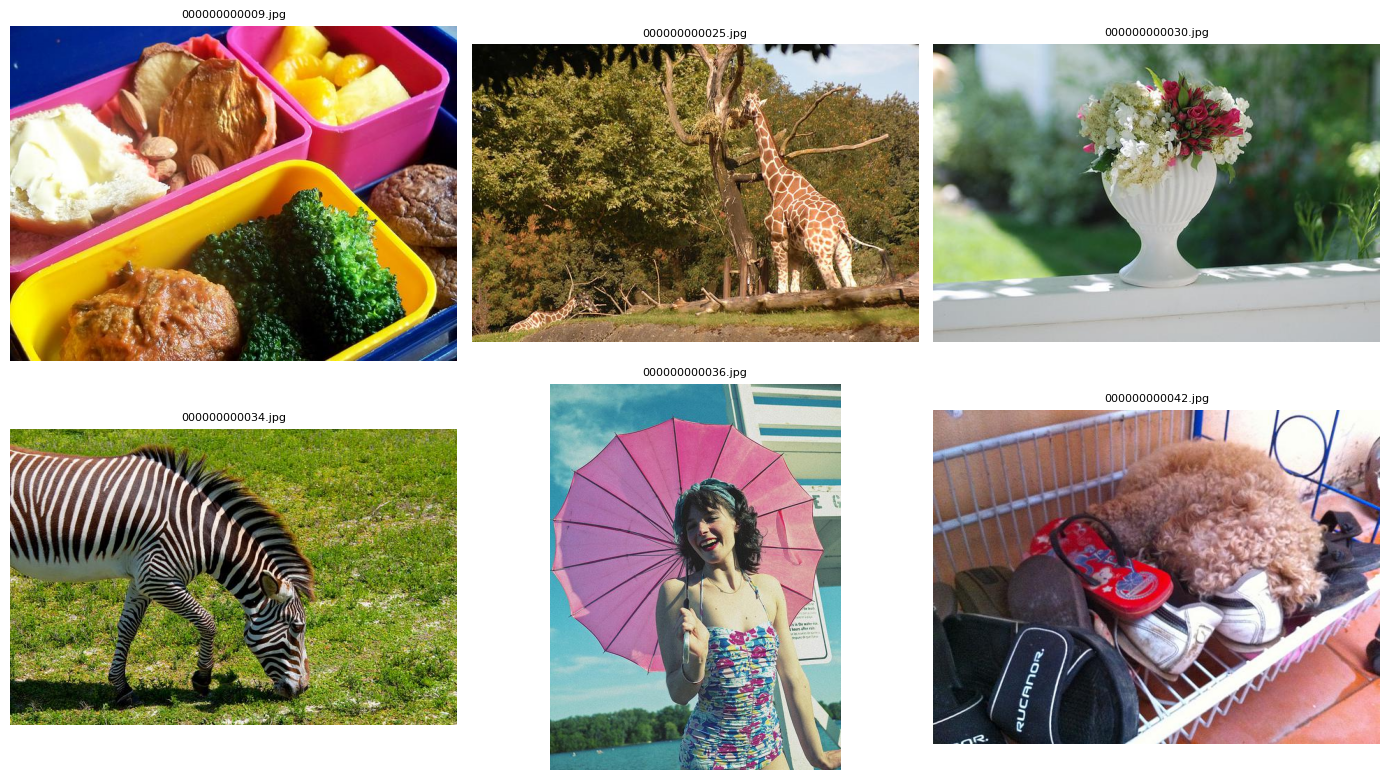

Saved: e:\Github\Machine-Learning-Projects\Computer Vision\Object Detection on COCO Subset\Source Code\coco_subset_eda_samples.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
sample_paths = train_imgs[:6]

for i in range(len(sample_paths)):
    img_bgr = cv2.imread(str(sample_paths[i]))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    axes.flat[i].imshow(img_rgb)
    axes.flat[i].set_title(sample_paths[i].name, fontsize=8)
    axes.flat[i].axis('off')

plt.tight_layout()
eda_path = ARTIFACT_DIR / 'coco_subset_eda_samples.png'
plt.savefig(eda_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {eda_path}')

## Train Detector (Ultralytics YOLO)

In [6]:
model = YOLO('yolov8n.pt')

train_results = model.train(
    data=str(data_yaml_path),
    epochs=1,
    imgsz=640,
    batch=16,
    device=DEVICE,
    project=str(RUNS_DIR),
    name='coco_subset_detect',
    exist_ok=True,
    workers=0
)

print('Training finished.')

e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


Ultralytics 8.4.38  Python-3.13.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=e:\Github\Machine-Learning-Projects\Computer Vision\Object Detection on COCO Subset\Source Code\data\coco128\coco128_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_sc

e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.10.0 ms, read: 306.3133.3 MB/s, size: 56.4 KB)
val: Scanning E:\Github\Machine-Learning-Projects\Computer Vision\Object Detection on COCO Subset\Source Code\data\coco128\labels\train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 16.8Mit/s 0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000119, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Plotting labels to E:\Github\Machine-Learning-Projects\Computer Vision\Object Detection on COCO Subset\Source Code\runs\coco_subset_detect\labels.jpg... 
Image sizes 640 train, 640 val
Using 0 data

## Evaluate with mAP

In [7]:
metrics = model.val(data=str(data_yaml_path), imgsz=640, batch=16, device=DEVICE, workers=0)

map50 = float(metrics.box.map50)
map5095 = float(metrics.box.map)
precision = float(metrics.box.mp)
recall = float(metrics.box.mr)

print(f'mAP@0.5:      {map50:.4f}')
print(f'mAP@0.5:0.95: {map5095:.4f}')
print(f'Precision:    {precision:.4f}')
print(f'Recall:       {recall:.4f}')

Ultralytics 8.4.38  Python-3.13.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 330.2137.3 MB/s, size: 44.1 KB)
val: Scanning E:\Github\Machine-Learning-Projects\Computer Vision\Object Detection on COCO Subset\Source Code\data\coco128\labels\train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 35.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 4.1it/s 2.0s0.2ss
                   all        128        929       0.68       0.52      0.605      0.448
                person         61        254      0.826      0.653      0.768      0.542
               bicycle          3          6      0.637      0.333      0.322      0.279
                   car         12         46      0.836      0.217      0.272      0.169
            motorcyc

## Sample Prediction Visualization

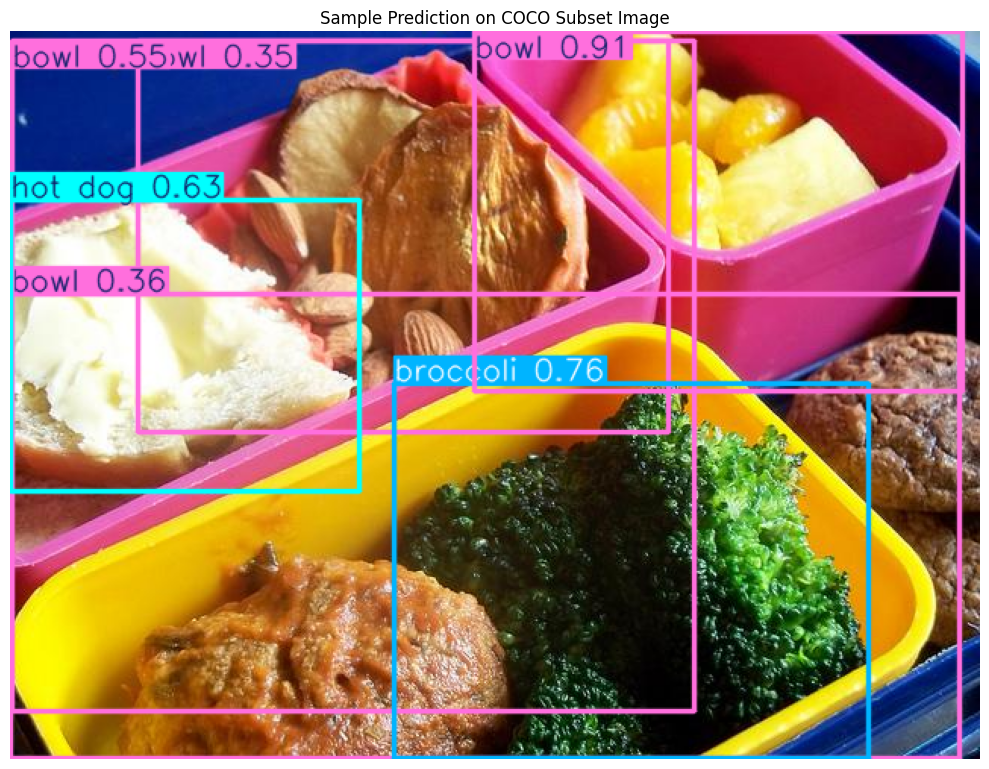

Saved: e:\Github\Machine-Learning-Projects\Computer Vision\Object Detection on COCO Subset\Source Code\coco_subset_sample_prediction.png


In [8]:
sample_image = str(train_imgs[0])
pred_results = model.predict(source=sample_image, conf=0.25, save=False, verbose=False)

pred_img_bgr = pred_results[0].plot()
pred_img_rgb = cv2.cvtColor(pred_img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(pred_img_rgb)
plt.title('Sample Prediction on COCO Subset Image')
plt.axis('off')

pred_path = ARTIFACT_DIR / 'coco_subset_sample_prediction.png'
plt.tight_layout()
plt.savefig(pred_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {pred_path}')

## Export Metrics and Summary

In [9]:
summary = {
    'project': 'Object Detection on COCO Subset',
    'dataset': 'COCO128 (subset of COCO)',
    'model': 'yolov8n',
    'epochs': 1,
    'imgsz': 640,
    'device': str(DEVICE),
    'metrics': {
        'map50': map50,
        'map50_95': map5095,
        'precision': precision,
        'recall': recall
    },
    'artifacts': [
        str(eda_path),
        str(pred_path)
    ]
}

metrics_path = ARTIFACT_DIR / 'coco_subset_metrics.json'
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

print('Notebook run complete.')
print(json.dumps(summary, indent=2))
print(f'Saved: {metrics_path}')

Notebook run complete.
{
  "project": "Object Detection on COCO Subset",
  "dataset": "COCO128 (subset of COCO)",
  "model": "yolov8n",
  "epochs": 1,
  "imgsz": 640,
  "device": "0",
  "metrics": {
    "map50": 0.6050049721600859,
    "map50_95": 0.4477141356594078,
    "precision": 0.6797428307519295,
    "recall": 0.5195360722135859
  },
  "artifacts": [
    "e:\\Github\\Machine-Learning-Projects\\Computer Vision\\Object Detection on COCO Subset\\Source Code\\coco_subset_eda_samples.png",
    "e:\\Github\\Machine-Learning-Projects\\Computer Vision\\Object Detection on COCO Subset\\Source Code\\coco_subset_sample_prediction.png"
  ]
}
Saved: e:\Github\Machine-Learning-Projects\Computer Vision\Object Detection on COCO Subset\Source Code\coco_subset_metrics.json


## Limitations and Next Steps

- This is a fast demonstration run (1 epoch) on a tiny subset.
- For stronger mAP, train longer and evaluate on a proper held-out split.
- Next extension: compare YOLO with torchvision Faster R-CNN on the same subset and latency budget.